In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load Iris dataset from sklearn
iris_raw = load_iris()


iris_df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)




In [2]:
iris_df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [3]:
iris_df['species_id'] = iris_raw.target
species_mapping = {i: name for i, name in enumerate(iris_raw.target_names)}
iris_df['species_name'] = iris_df['species_id'].map(species_mapping)

print("Iris dimensions:", iris_df.shape)
print("Missing entries checking:\n", iris_df.isnull().sum())
print(iris_df.head(3))


Iris dimensions: (150, 6)
Missing entries checking:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species_name         0
dtype: int64
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [4]:
for col in iris_raw.feature_names:
    mean_val = iris_df[col].mean()
    median_val = iris_df[col].median()
    mode_val = iris_df[col].mode()[0]
    print(f"Feature: {col}")
    print(f"  Mean:   {mean_val:.4f} cm")
    print(f"  Median: {median_val:.4f} cm")
    print(f"  Mode:   {mode_val:.4f} cm")
    print("-" * 40)

Feature: sepal length (cm)
  Mean:   5.8433 cm
  Median: 5.8000 cm
  Mode:   5.0000 cm
----------------------------------------
Feature: sepal width (cm)
  Mean:   3.0573 cm
  Median: 3.0000 cm
  Mode:   3.0000 cm
----------------------------------------
Feature: petal length (cm)
  Mean:   3.7580 cm
  Median: 4.3500 cm
  Mode:   1.4000 cm
----------------------------------------
Feature: petal width (cm)
  Mean:   1.1993 cm
  Median: 1.3000 cm
  Mode:   0.2000 cm
----------------------------------------


In [5]:
for col in iris_raw.feature_names:
    variance = iris_df[col].var()
    std_dev = iris_df[col].std()
    data_range = iris_df[col].max() - iris_df[col].min()
    q1 = iris_df[col].quantile(0.25)
    q3 = iris_df[col].quantile(0.75)
    print(f"Feature: {col}")
    print(f"  Variance:           {variance:.4f}")
    print(f"  Std Deviation:      {std_dev:.4f}")
    print(f"  Range (Max - Min):  {data_range:.4f}")
    print(f"  IQR (Q3 - Q1):      {q3 - q1:.4f}")
    print("-" * 40)

Feature: sepal length (cm)
  Variance:           0.6857
  Std Deviation:      0.8281
  Range (Max - Min):  3.6000
  IQR (Q3 - Q1):      1.3000
----------------------------------------
Feature: sepal width (cm)
  Variance:           0.1900
  Std Deviation:      0.4359
  Range (Max - Min):  2.4000
  IQR (Q3 - Q1):      0.5000
----------------------------------------
Feature: petal length (cm)
  Variance:           3.1163
  Std Deviation:      1.7653
  Range (Max - Min):  5.9000
  IQR (Q3 - Q1):      3.5000
----------------------------------------
Feature: petal width (cm)
  Variance:           0.5810
  Std Deviation:      0.7622
  Range (Max - Min):  2.4000
  IQR (Q3 - Q1):      1.5000
----------------------------------------


In [6]:
for col in iris_raw.feature_names:
    skewness = iris_df[col].skew()
    kurtosis = iris_df[col].kurt()
    print(f"Feature: {col}")
    print(f"  Skewness (Asymmetry): {skewness:.4f}")
    print(f"  Kurtosis (Tails):     {kurtosis:.4f}")
    print("-" * 40)

Feature: sepal length (cm)
  Skewness (Asymmetry): 0.3149
  Kurtosis (Tails):     -0.5521
----------------------------------------
Feature: sepal width (cm)
  Skewness (Asymmetry): 0.3190
  Kurtosis (Tails):     0.2282
----------------------------------------
Feature: petal length (cm)
  Skewness (Asymmetry): -0.2749
  Kurtosis (Tails):     -1.4021
----------------------------------------
Feature: petal width (cm)
  Skewness (Asymmetry): -0.1030
  Kurtosis (Tails):     -1.3406
----------------------------------------


In [7]:
grouped_species = iris_df.groupby('species_name')

print("--- Group-Wise Mean Values ---")
print(grouped_species[iris_raw.feature_names].mean())

print("\n--- Group-Wise Standard Deviation Profiles ---")
print(grouped_species[iris_raw.feature_names].std())


aggregated_stats = iris_df.groupby('species_name')['petal length (cm)'].agg(['mean', 'median', 'std', 'skew'])
print("Aggregated Statistics (Petal Length):\n", aggregated_stats)



--- Group-Wise Mean Values ---
              sepal length (cm)  sepal width (cm)  petal length (cm)  \
species_name                                                           
setosa                    5.006             3.428              1.462   
versicolor                5.936             2.770              4.260   
virginica                 6.588             2.974              5.552   

              petal width (cm)  
species_name                    
setosa                   0.246  
versicolor               1.326  
virginica                2.026  

--- Group-Wise Standard Deviation Profiles ---
              sepal length (cm)  sepal width (cm)  petal length (cm)  \
species_name                                                           
setosa                 0.352490          0.379064           0.173664   
versicolor             0.516171          0.313798           0.469911   
virginica              0.635880          0.322497           0.551895   

              petal width (cm)  
s

In [8]:
print(iris_df.head(7))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  
3           0       setosa  
4           0       setosa  
5           0       setosa  
6           0       setosa  


In [9]:
print(iris_df.head(15))


    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 5.0               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                1.5               0.2   
11                4.8               3.4 

In [10]:
print(iris_df.head(9))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  
3           0       setosa  
4           0       setosa  
5           0       setosa  
6     

In [11]:
print(iris_df.head(75))


    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
..                ...               ...                ...               ...   
70                5.9               3.2                4.8               1.8   
71                6.1               2.8                4.0               1.3   
72                6.3               2.5                4.9               1.5   
73                6.1               2.8                4.7               1.2   
74                6.4               2.9                4.3               1.3   

    species_id species_name  
0        

In [12]:
print(iris_df.head(150))


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     species_id species_nam

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Iris Dataset
df = sns.load_dataset("iris")

# Display first five rows
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


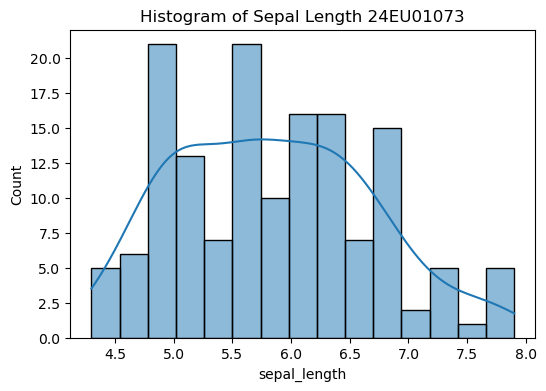

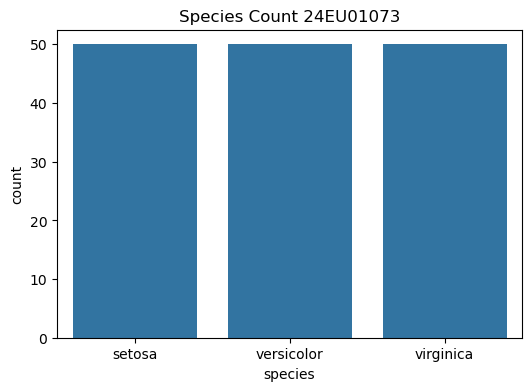

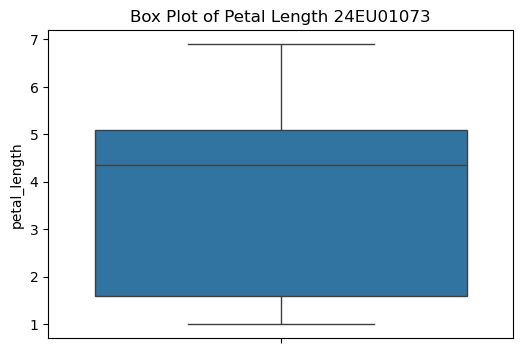

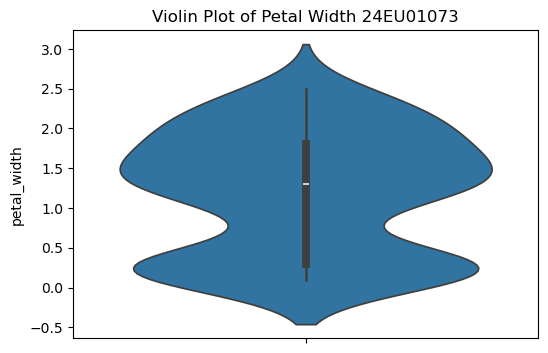

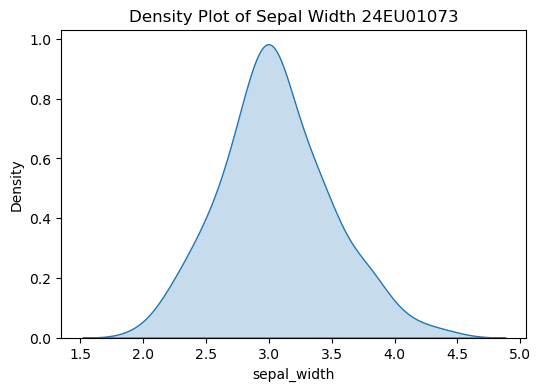

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df["sepal_length"], bins=15, kde=True)
plt.title("Histogram of Sepal Length 24EU01073")
plt.show()

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Species Count 24EU01073")
plt.show()

# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(y="petal_length", data=df)
plt.title("Box Plot of Petal Length 24EU01073")
plt.show()

# Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(y="petal_width", data=df)
plt.title("Violin Plot of Petal Width 24EU01073")
plt.show()

# Density Plot
plt.figure(figsize=(6,4))
sns.kdeplot(df["sepal_width"], fill=True)
plt.title("Density Plot of Sepal Width 24EU01073")
plt.show()

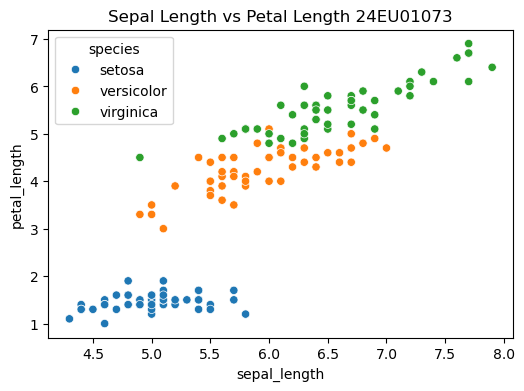

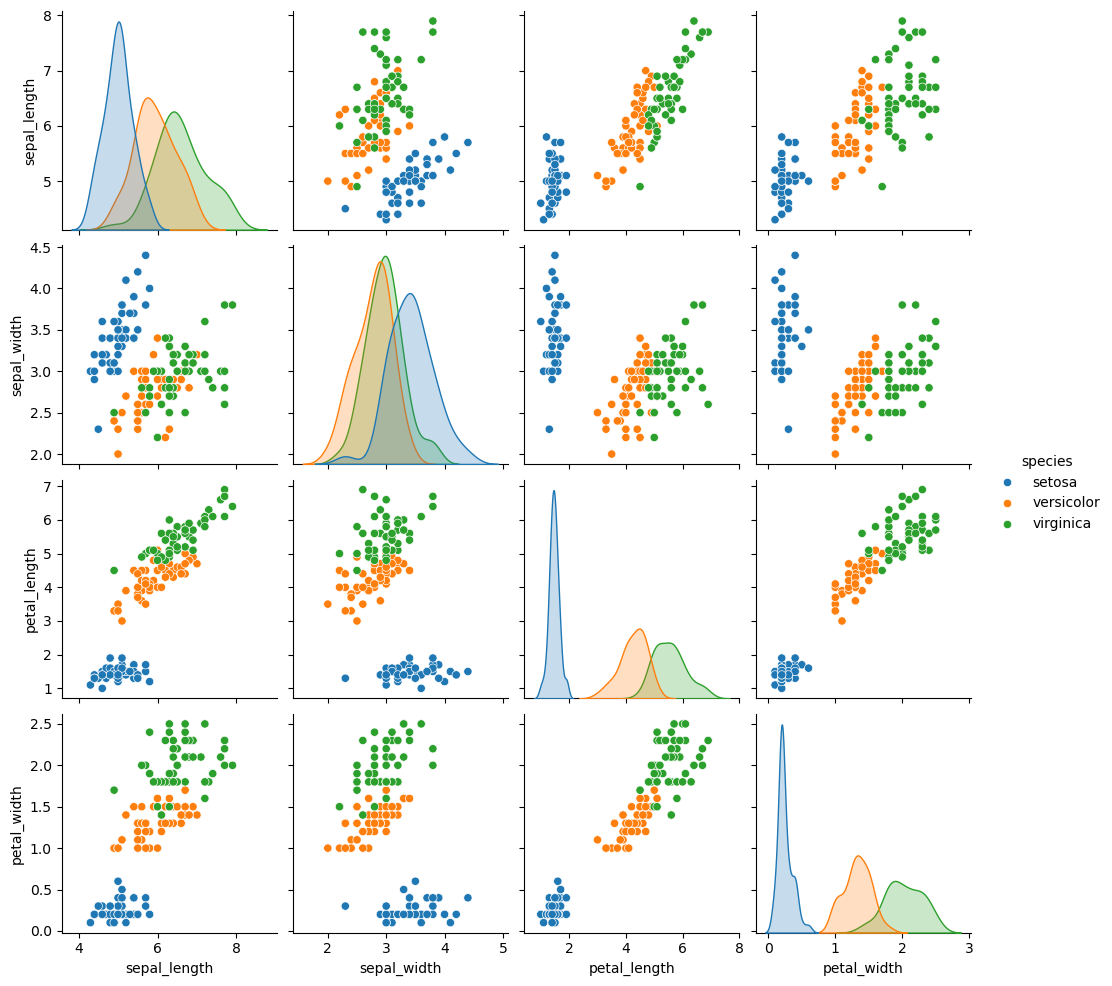

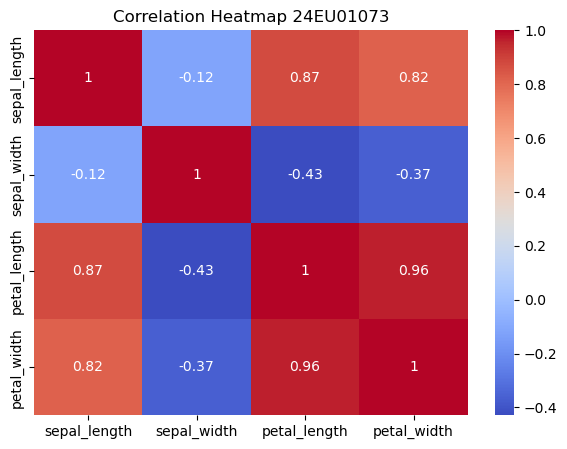

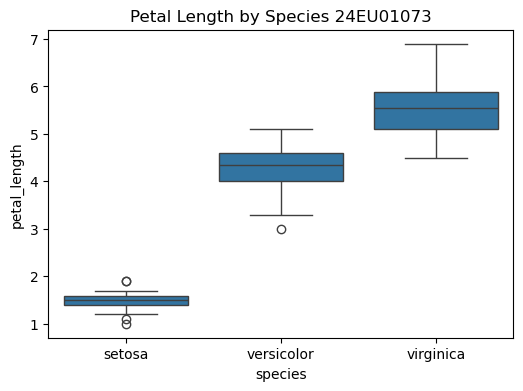

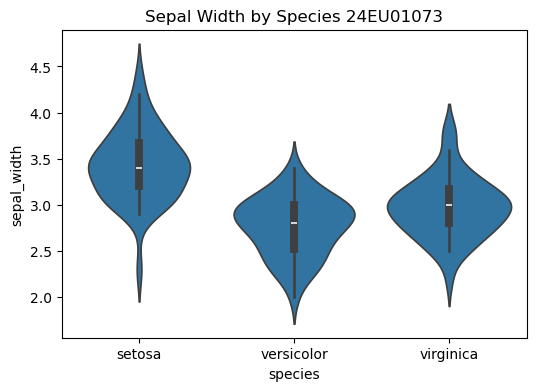

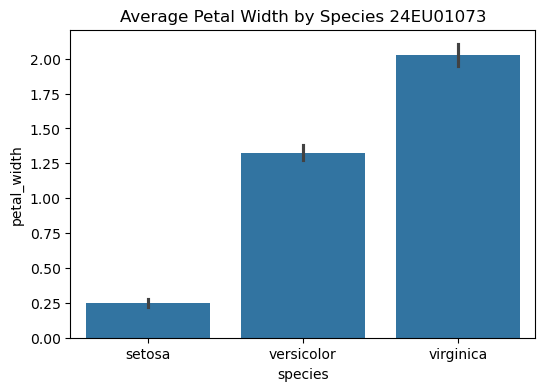

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="sepal_length", y="petal_length",
                hue="species", data=df)
plt.title("Sepal Length vs Petal Length 24EU01073")
plt.show()

# Pair Plot
sns.pairplot(df, hue="species")
plt.savefig('fig2')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap 24EU01073")
plt.show()

# Box Plot by Species
plt.figure(figsize=(6,4))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Petal Length by Species 24EU01073")
plt.show()

# Violin Plot by Species
plt.figure(figsize=(6,4))
sns.violinplot(x="species", y="sepal_width", data=df)
plt.title("Sepal Width by Species 24EU01073")
plt.show()

# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(x="species", y="petal_width", data=df)
plt.title("Average Petal Width by Species 24EU01073")
plt.savefig('fig')
plt.show()

In [ ]:
data=pd.read_csv('')